In [30]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

In [2]:
df = pl.read_parquet("../final_patient_data.parquet")


In [3]:
df.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1


In [4]:
cv_cols = [
    "Cardiopathie ischémique",
    "Fibrillation atriale",
    "Insuffisance cardiaque chronique",
    "Pacemaker",
    "Pontage aorto-coronarien",
    "Antécédent d'AVC",
]
df = df.with_columns(
    (
        pl.sum_horizontal([pl.col(c) for c in cv_cols]) >= 1
    )
    .cast(pl.Int8)
    .alias("cv_history")
)

In [5]:
df.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag,cv_history
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32,i8
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1,1


In [6]:
df = df.select([
    "patient_id", "hosp_admission_datetime", "death_date", "icu_stay_flag", "cv_history"
])

In [7]:
df.head(5)

patient_id,hosp_admission_datetime,death_date,icu_stay_flag,cv_history
str,datetime[μs],date,i8,i8
"""P001""",2018-07-04 11:15:00,2018-09-21,0,1
"""P002""",2019-01-18 13:20:00,null,0,0
"""P003""",2019-04-09 09:15:00,2020-12-04,0,1
"""P004""",2018-03-03 07:50:00,null,1,1
"""P005""",2019-02-01 14:10:00,2019-03-17,0,0


In [8]:
df = df.to_pandas()

In [9]:
# Convert to datetime and then extract the date only
# Normalize the time component to 00:00:00
df["hosp_admission_datetime"] = pd.to_datetime(df["hosp_admission_datetime"]).dt.normalize()
df["death_date"] = pd.to_datetime(df["death_date"]).dt.normalize()

In [10]:
# Create a one-year follow-up limit for each patient (admission date + 365 days)
df["one_year_limit"] = df["hosp_admission_datetime"]+pd.Timedelta(days=365)

In [11]:
df.head(1)

,patient_id,hosp_admission_datetime,death_date,icu_stay_flag,cv_history,one_year_limit
0,P001,2018-07-04,2018-09-21,0,1,2019-07-04


In [12]:
# Define the actual end of follow-up for each patient:
# use the death date if available; otherwise, use the one-year limit
df["end_followup"] = df["death_date"].fillna(df["one_year_limit"])

# If the death date is beyond the one-year limit, censor follow-up at the one-year limit
df.loc[df["end_followup"] > df["one_year_limit"], "end_followup"] = (df["one_year_limit"])

In [13]:
# 3. Calculate the elapsed follow-up time in days
# This is the time variable used in the Kaplan-Meier estimator
df["time"] = (
    df["end_followup"]-df["hosp_admission_datetime"]
).dt.days

In [14]:
# 4. Determine whether death occurred within this follow-up period
# This is the status/event variable
df["status"] = (df["death_date"].notna()) & (
    df["death_date"] < df["one_year_limit"]
)

In [15]:
df.head()

,patient_id,hosp_admission_datetime,death_date,icu_stay_flag,cv_history,one_year_limit,end_followup,time,status
0,P001,2018-07-04,2018-09-21,0,1,2019-07-04,2018-09-21,79,True
1,P002,2019-01-18,NaT,0,0,2020-01-18,2020-01-18,365,False
2,P003,2019-04-09,2020-12-04,0,1,2020-04-08,2020-04-08,365,False
3,P004,2018-03-03,NaT,1,1,2019-03-03,2019-03-03,365,False
4,P005,2019-02-01,2019-03-17,0,0,2020-02-01,2019-03-17,44,True


In [16]:
df_surv = df.loc[
    df['icu_stay_flag'] == 0,
    ['patient_id',  'time', 'status', 'cv_history']
].copy()

In [17]:
df_surv.head()

,patient_id,time,status,cv_history
0,P001,79,True,1
1,P002,365,False,0
2,P003,365,False,1
4,P005,44,True,0
5,P006,365,False,0


In [18]:
df_surv[df_surv['time']<0]

,patient_id,time,status,cv_history


In [19]:
df_surv = df_surv[df_surv['time']>= 0]

In [20]:
df_surv.isna().sum()

patient_id    0
time          0
status        0
cv_history    0
dtype: int64

In [21]:
df_surv['cv_history'].unique()

array([1, 0], dtype=int8)

In [22]:
df_surv.shape

(8, 4)

In [23]:
cv_mask = df_surv["cv_history"]== 1
no_cv_mask =df_surv["cv_history"]== 0

In [24]:
print("CV:", cv_mask.sum())
print("No-CV:", no_cv_mask.sum())

CV: 3
No-CV: 5


In [25]:
table_2x2 = pd.DataFrame(
    {
        "Death within 1 year": [
            df_surv.loc[cv_mask, "status"].sum(),
            df_surv.loc[no_cv_mask, "status"].sum(),
        ],
        "Alive at 1 year": [
            (~df_surv.loc[cv_mask, "status"].astype(bool)).sum(),
            (~df_surv.loc[no_cv_mask, "status"].astype(bool)).sum(),
        ],
    },
    index=["CV history", "No CV history"]
)

table_2x2["Total"] = table_2x2.sum(axis=1)
table_2x2.loc["Total"] = table_2x2.sum(axis=0)

table_2x2

,Death within 1 year,Alive at 1 year,Total
CV history,2,1,3
No CV history,1,4,5
Total,3,5,8


In [26]:
death_percentage = (
    table_2x2["Death within 1 year"]
    / table_2x2["Total"]
    * 100
)

death_percentage

CV history       66.666667
No CV history    20.000000
Total            37.500000
dtype: float64

In [27]:
kmf_cv = KaplanMeierFitter()
kmf_no_cv = KaplanMeierFitter()

kmf_cv.fit(
    durations = df_surv.loc[cv_mask, "time"], 
    event_observed = df_surv.loc[cv_mask, "status"],
    label = "CV"
)

kmf_no_cv.fit(
    durations = df_surv.loc[no_cv_mask, "time"], 
    event_observed = df_surv.loc[no_cv_mask, "status"],
    label = "No_CV"
)

<lifelines.KaplanMeierFitter:"No_CV", fitted with 5 total observations, 4 right-censored observations>

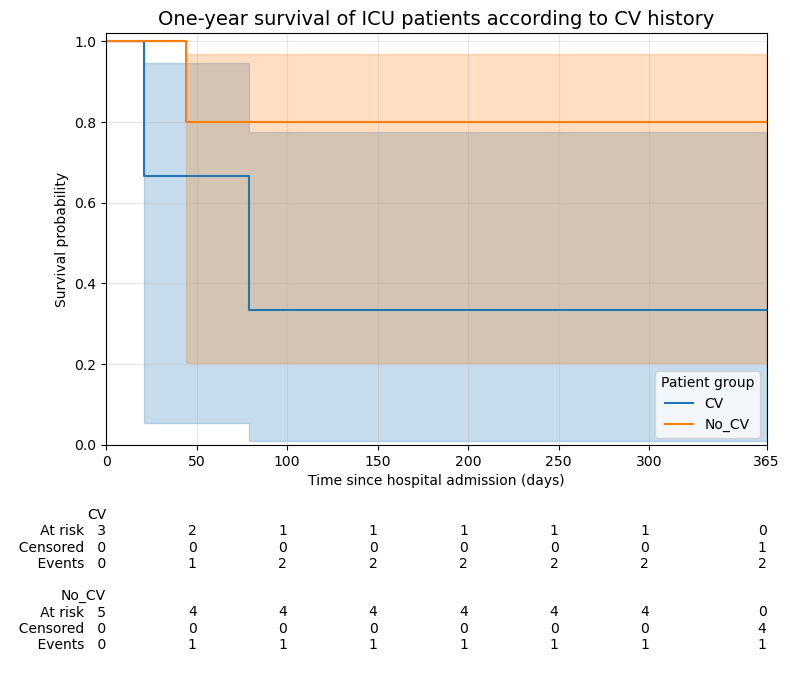

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

kmf_cv.plot_survival_function(
    ax=ax,
    ci_show=True
)

kmf_no_cv.plot_survival_function(
    ax=ax,
    ci_show=True
)

time_points = [0, 50, 100, 150, 200, 250, 300, 365]

ax.set_xlim(0, 365)
ax.set_xticks(time_points)

add_at_risk_counts(
    kmf_cv,
    kmf_no_cv,
    ax=ax,
    xticks=time_points
)

ax.set_ylim(0, 1.02)

ax.set_title(
    "One-year survival of ICU patients according to CV history",
    fontsize=14
)

ax.set_xlabel("Time since hospital admission (days)")
ax.set_ylabel("Survival probability")

ax.grid(alpha=0.3)
ax.legend(title="Patient group")

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

plt.show()

In [32]:
contingency_table = pd.crosstab(
    df_surv["cv_history"].map({0: "No CV history", 1: "CV history"}),
    df_surv["status"].map({False: "Alive at 1 year", True: "Dead within 1 year"}),
    margins=True
)

contingency_table

status,Alive at 1 year,Dead within 1 year,All
cv_history,,,
CV history,1,2,3
No CV history,4,1,5
All,5,3,8


In [33]:
from scipy.stats import chi2_contingency

chi2_table = pd.crosstab(
    df_surv["cv_history"].map({0: "No CV history", 1: "CV history"}),
    df_surv["status"].map({False: "Alive at 1 year", True: "Dead within 1 year"}),
)

chi2, p_value, dof, expected = chi2_contingency(chi2_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)
print("Expected frequencies:")
print(expected)

Chi-square statistic: 0.32
Degrees of freedom: 1
p-value: 0.5716076449533314
Expected frequencies:
[[1.875 1.125]
 [3.125 1.875]]


In [34]:
from lifelines.statistics import logrank_test

logrank_result = logrank_test(
    durations_A = df_surv.loc[cv_mask, "time"],
    durations_B = df_surv.loc[no_cv_mask, "time"],
    event_observed_A=df_surv.loc[cv_mask, "status"],
    event_observed_B=df_surv.loc[no_cv_mask, "status"]
)

In [35]:
print("Log-rank test statistic:", logrank_result.test_statistic)
print("p-value:", logrank_result.p_value)

Log-rank test statistic: 1.5316672923258434
p-value: 0.2158623862761796
